# Uber Ride Analytics Dashboard – NCR Region

**End-to-end EDA and Dashboard Project**  
Dataset: `uber_ride_bookings.csv` (Kaggle – Uber Ride Analytics)  
Objective: Analyze NCR ride bookings for trends, demand, cancellations, vehicle performance; present via Power BI.

---
## STEP 1: Data Gathering



In [6]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('uber_ride_bookings.csv', na_values=['null'])
print('Data loaded from CSV.')

display(df.head())
print('\nDataset shape:', df.shape)

Data loaded from CSV.


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI



Dataset shape: (150000, 21)


---
## STEP 2: Data Cleaning & Preprocessing
---

1. Check missing values, duplicates, data types  
2. Handle missing: drop high-null columns, median for numeric, 'Unknown' for categorical  
3. Convert date/time to datetime  
4. Feature engineering: hour, day, weekday, month, ride_duration, weekend flag  
5. Remove/flag invalid records (negative distance, zero fare)

In [8]:
print(df.isnull().sum())

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64


In [9]:
print((df.isnull().sum() / len(df) * 100).round(2))

Date                                  0.0
Time                                  0.0
Booking ID                            0.0
Booking Status                        0.0
Customer ID                           0.0
Vehicle Type                          0.0
Pickup Location                       0.0
Drop Location                         0.0
Avg VTAT                              7.0
Avg CTAT                             32.0
Cancelled Rides by Customer          93.0
Reason for cancelling by Customer    93.0
Cancelled Rides by Driver            82.0
Driver Cancellation Reason           82.0
Incomplete Rides                     94.0
Incomplete Rides Reason              94.0
Booking Value                        32.0
Ride Distance                        32.0
Driver Ratings                       38.0
Customer Rating                      38.0
Payment Method                       32.0
dtype: float64


In [10]:
dup_count = df.duplicated().sum()
print(f'Duplicates: {dup_count}')

Duplicates: 0


In [11]:
print(df.dtypes)

Date                                  object
Time                                  object
Booking ID                            object
Booking Status                        object
Customer ID                           object
Vehicle Type                          object
Pickup Location                       object
Drop Location                         object
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer     object
Cancelled Rides by Driver            float64
Driver Cancellation Reason            object
Incomplete Rides                     float64
Incomplete Rides Reason               object
Booking Value                        float64
Ride Distance                        float64
Driver Ratings                       float64
Customer Rating                      float64
Payment Method                        object
dtype: object


In [12]:
print('Columns:', list(df.columns))

Columns: ['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method']


In [13]:
date_cols = [c for c in df.columns if c in ['Date', 'Time']]
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print('Date/time:', date_cols, '| Numeric:', numeric_cols[:5], '... | Object cols:', len(cat_cols))

Date/time: ['Date', 'Time'] | Numeric: ['Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Cancelled Rides by Driver', 'Incomplete Rides'] ... | Object cols: 12


In [14]:
#Handle missing values ---
df_clean = df.copy()

for col in ['Booking Value', 'Ride Distance', 'Avg VTAT', 'Avg CTAT']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

null_pct = df_clean.isnull().sum() / len(df_clean) * 100
high_null = null_pct[null_pct > 50].index.tolist()

key_cols = ['Date', 'Time', 'Booking ID', 'Booking Status', 'Vehicle Type', 'Booking Value', 'Ride Distance',
            'Reason for cancelling by Customer', 'Driver Cancellation Reason', 'Incomplete Rides Reason']
drop_candidates = [c for c in high_null if c not in key_cols]
if drop_candidates:
    df_clean = df_clean.drop(columns=drop_candidates)
    print('Dropped high-null columns:', drop_candidates)

# Fill continuous with median
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        print(f'Filled {col} with median')

# Fill categorical with 'Unknown'
for col in df_clean.select_dtypes(include=['object']).columns:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna('Unknown')
        print(f'Filled {col} with Unknown')

print('\nRemaining nulls:', df_clean.isnull().sum().sum())

Dropped high-null columns: ['Cancelled Rides by Customer', 'Cancelled Rides by Driver', 'Incomplete Rides']
Filled Avg VTAT with median
Filled Avg CTAT with median
Filled Booking Value with median
Filled Ride Distance with median
Filled Driver Ratings with median
Filled Customer Rating with median
Filled Reason for cancelling by Customer with Unknown
Filled Driver Cancellation Reason with Unknown
Filled Incomplete Rides Reason with Unknown
Filled Payment Method with Unknown

Remaining nulls: 0


In [15]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')
df_clean['booking_datetime'] = pd.to_datetime(df_clean['Date'].astype(str) + ' ' + df_clean['Time'].astype(str), errors='coerce')

if 'Booking ID' in df_clean.columns:
    df_clean['Booking ID'] = df_clean['Booking ID'].astype(str).str.replace('"', '', regex=False)

In [16]:
dt_series = df_clean['booking_datetime']
df_clean['booking_hour'] = dt_series.dt.hour
df_clean['booking_day'] = dt_series.dt.day
df_clean['booking_weekday'] = dt_series.dt.dayofweek  # 0=Monday
df_clean['booking_month'] = dt_series.dt.month
df_clean['weekend_flag'] = df_clean['booking_weekday'].isin([5, 6]).astype(int)  # Sat=5, Sun=6


df_clean['ride_duration_mins'] = df_clean['Avg VTAT'].fillna(0) + df_clean['Avg CTAT'].fillna(0)
df_clean.loc[(df_clean['ride_duration_mins'] == 0), 'ride_duration_mins'] = np.nan
print('Created ride_duration_mins from Avg VTAT + Avg CTAT')

def get_reason(row):
    for col in ['Reason for cancelling by Customer', 'Driver Cancellation Reason', 'Incomplete Rides Reason']:
        val = row.get(col)
        if pd.notna(val) and str(val).strip() and str(val) not in ('Unknown', 'nan'):
            return str(val).strip()
    return 'Unknown'
df_clean['cancellation_reason'] = df_clean.apply(get_reason, axis=1)
print('New columns: booking_hour, booking_day, booking_weekday, booking_month, weekend_flag, ride_duration_mins, cancellation_reason')

Created ride_duration_mins from Avg VTAT + Avg CTAT
New columns: booking_hour, booking_day, booking_weekday, booking_month, weekend_flag, ride_duration_mins, cancellation_reason


In [17]:
invalid_mask = pd.Series(False, index=df_clean.index)
if 'Ride Distance' in df_clean.columns:
    invalid_mask |= (pd.to_numeric(df_clean['Ride Distance']) < 0)
if 'Booking Value' in df_clean.columns:
    invalid_mask |= (pd.to_numeric(df_clean['Booking Value']) < 0)
if 'ride_duration_mins' in df_clean.columns:
    invalid_mask |= (df_clean['ride_duration_mins'] < 0)

df_clean = df_clean[~invalid_mask].copy()
print('Cleaned shape:', df_clean.shape)

Cleaned shape: (150000, 26)


In [18]:
df_clean = df_clean.drop_duplicates()

In [19]:
df_clean.to_csv('cleaned_ncr_ride_bookings.csv', index=False)

In [20]:
df_clean.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Customer Rating,Payment Method,booking_datetime,booking_hour,booking_day,booking_weekday,booking_month,weekend_flag,ride_duration_mins,cancellation_reason
0,2024-03-23,12:29:38,CNR5884300,No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.3,28.8,...,4.5,Unknown,2024-03-23 12:29:38,12,23,5,3,1,37.1,Unknown
1,2024-11-29,18:01:39,CNR1326809,Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,4.5,UPI,2024-11-29 18:01:39,18,29,4,11,0,18.9,Vehicle Breakdown
2,2024-08-23,08:56:10,CNR8494506,Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,4.9,Debit Card,2024-08-23 08:56:10,8,23,4,8,0,39.2,Unknown
3,2024-10-21,17:17:25,CNR8906825,Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,5.0,UPI,2024-10-21 17:17:25,17,21,0,10,0,41.6,Unknown
4,2024-09-16,22:08:00,CNR1950162,Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,4.3,UPI,2024-09-16 22:08:00,22,16,0,9,0,24.9,Unknown


In [74]:
import numpy as np
# Handling outliers
# List only the numeric columns where outliers make sense
outlier_cols = [
    'ride_distance',
    'fare_amount',
    'driver_waiting_time',
    'avg_vtat',
    'avg_ctat'
]

for col in outlier_cols:
    if col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Capping outliers
        df_clean[col] = np.where(
            df_clean[col] < lower_bound,
            lower_bound,
            np.where(df_clean[col] > upper_bound, upper_bound, df_clean[col])
        )


In [22]:
df_clean.dtypes

Date                                 datetime64[ns]
Time                                         object
Booking ID                                   object
Booking Status                               object
Customer ID                                  object
Vehicle Type                                 object
Pickup Location                              object
Drop Location                                object
Avg VTAT                                    float64
Avg CTAT                                    float64
Reason for cancelling by Customer            object
Driver Cancellation Reason                   object
Incomplete Rides Reason                      object
Booking Value                               float64
Ride Distance                               float64
Driver Ratings                              float64
Customer Rating                             float64
Payment Method                               object
booking_datetime                     datetime64[ns]
booking_hour

---
## STEP 3: Exploratory Data Analysis (EDA)
---

A. Descriptive statistics  
B. Trend analysis (hourly, daily, monthly, weekday vs weekend)  
C. Vehicle analysis  
D. Cancellation analysis  
E. Visualizations

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = pd.read_csv('cleaned_ncr_ride_bookings.csv')
df_clean['booking_datetime'] = pd.to_datetime(df_clean['booking_datetime'])
wd_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

### A. Descriptive Statistics

In [26]:
status_col = 'Booking Status'
fare_col = 'Booking Value'
dist_col = 'Ride Distance'
vt_col = 'Vehicle Type'

total_bookings = len(df_clean)
completed = df_clean[df_clean[status_col].astype(str).str.contains('Completed', case=False, na=False)]
cancelled = df_clean[~df_clean[status_col].astype(str).str.contains('Completed', case=False, na=False)]

print('=== Descriptive Statistics ===')
print(f'Total bookings: {total_bookings:,}')
print(f'Completed rides: {len(completed):,}')
print(f'Cancelled/Other (No Driver, Incomplete, Cancelled by Driver/Customer): {len(cancelled):,}')
print(f'Non-completion rate: {len(cancelled)/total_bookings*100:.2f}%')
print(f'Average Ride Distance (km): {df_clean[dist_col].mean():.2f}')
print(f'Average Booking Value (fare): {df_clean[fare_col].mean():.2f}')
if 'ride_duration_mins' in df_clean.columns:
    print(f'Average ride duration (mins, VTAT+CTAT): {df_clean["ride_duration_mins"].mean():.2f}')

=== Descriptive Statistics ===
Total bookings: 150,000
Completed rides: 93,000
Cancelled/Other (No Driver, Incomplete, Cancelled by Driver/Customer): 57,000
Non-completion rate: 38.00%
Average Ride Distance (km): 24.34
Average Booking Value (fare): 478.12
Average ride duration (mins, VTAT+CTAT): 37.48


In [27]:
df_clean.describe()

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,booking_datetime,booking_hour,booking_day,booking_weekday,booking_month,weekend_flag,ride_duration_mins
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.00000
mean,8.445407,29.037753,478.121220,24.343568,4.257215,4.440842,2024-07-01 07:14:41.251033344,14.034113,15.646087,2.996987,6.490940,0.286267,37.48316
min,2.000000,10.000000,50.000000,1.000000,3.000000,3.000000,2024-01-01 00:19:34,0.000000,1.000000,0.000000,1.000000,0.000000,12.30000
25%,5.600000,25.000000,319.750000,17.360000,4.200000,4.300000,2024-03-31 22:55:36.249999872,10.000000,8.000000,1.000000,3.000000,0.000000,32.50000
50%,8.300000,28.800000,414.000000,23.720000,4.300000,4.500000,2024-07-01 09:24:52.500000,15.000000,16.000000,3.000000,7.000000,0.000000,37.10000
75%,11.000000,32.900000,521.000000,30.650000,4.300000,4.600000,2024-09-30 13:46:07.249999872,18.000000,23.000000,5.000000,9.000000,1.000000,42.80000
max,20.000000,45.000000,4277.000000,50.000000,5.000000,5.000000,2024-12-30 23:36:11,23.000000,31.000000,6.000000,12.000000,1.000000,60.00000
std,3.639311,7.343053,329.339976,11.554362,0.345619,0.347835,NaN,5.416906,8.781698,2.003202,3.444028,0.452017,8.35980


### B. Trend Analysis – Hourly, Daily, Monthly, Weekday vs Weekend

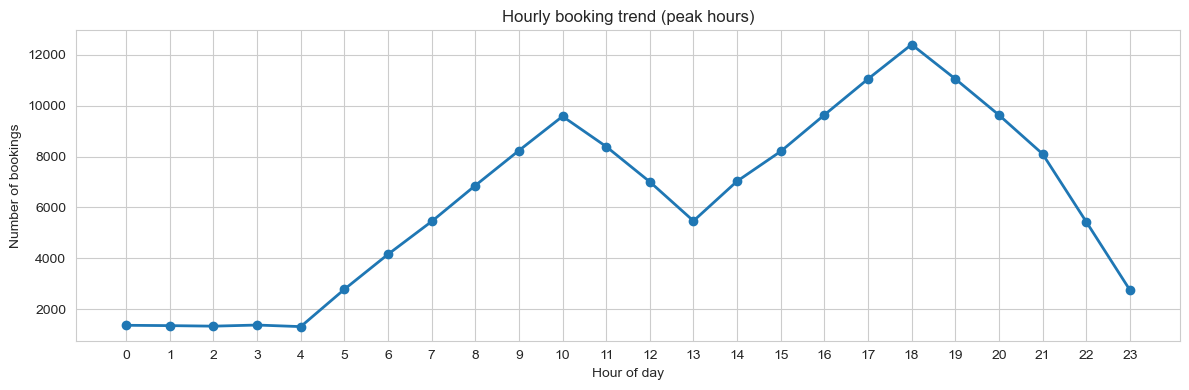

In [29]:
hourly = df_clean.groupby('booking_hour').size().reset_index(name='bookings')
plt.figure(figsize=(12, 4))
plt.plot(hourly['booking_hour'], hourly['bookings'], marker='o', linewidth=2)
plt.xlabel('Hour of day')
plt.ylabel('Number of bookings')
plt.title('Hourly booking trend (peak hours)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

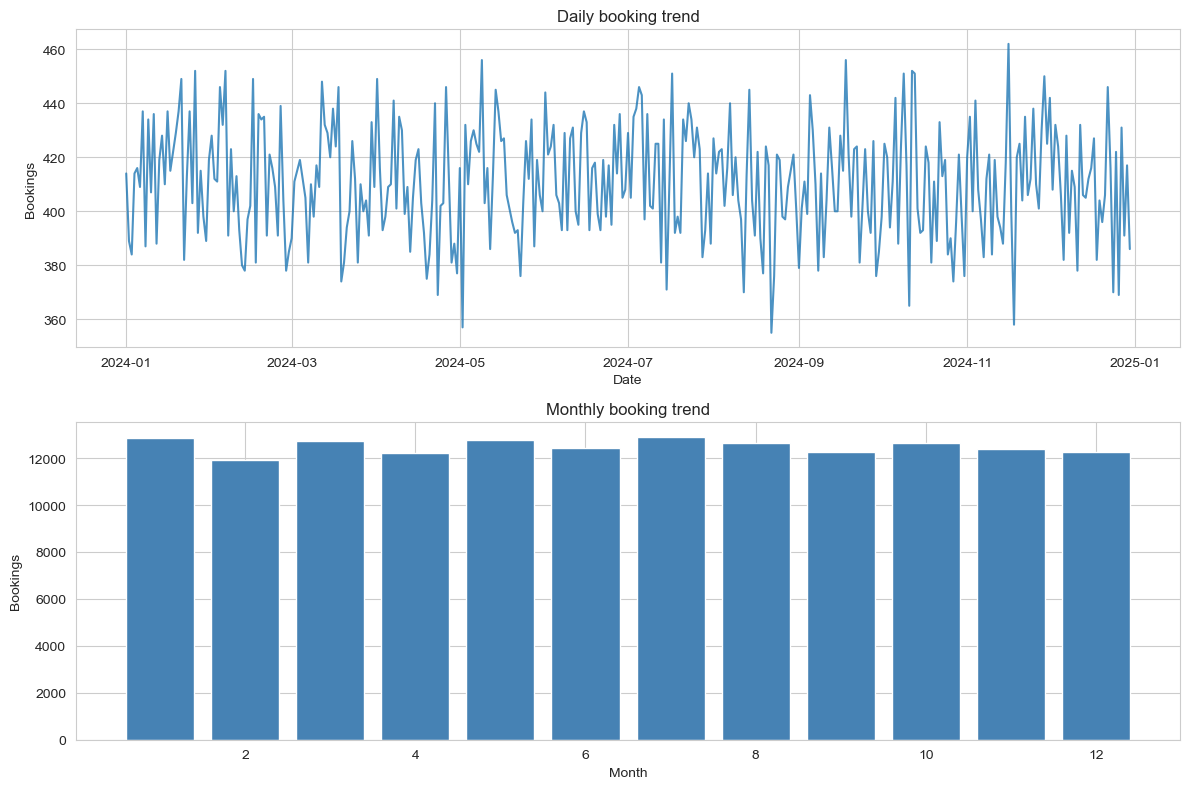

In [30]:
df_clean['date'] = df_clean['booking_datetime'].dt.date
daily = df_clean.groupby('date').size().reset_index(name='bookings')
monthly = df_clean.groupby('booking_month').size().reset_index(name='bookings')

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(daily['date'], daily['bookings'], alpha=0.8)
axes[0].set_title('Daily booking trend')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Bookings')
axes[1].bar(monthly['booking_month'], monthly['bookings'], color='steelblue')
axes[1].set_title('Monthly booking trend')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Bookings')
plt.tight_layout()
plt.show()

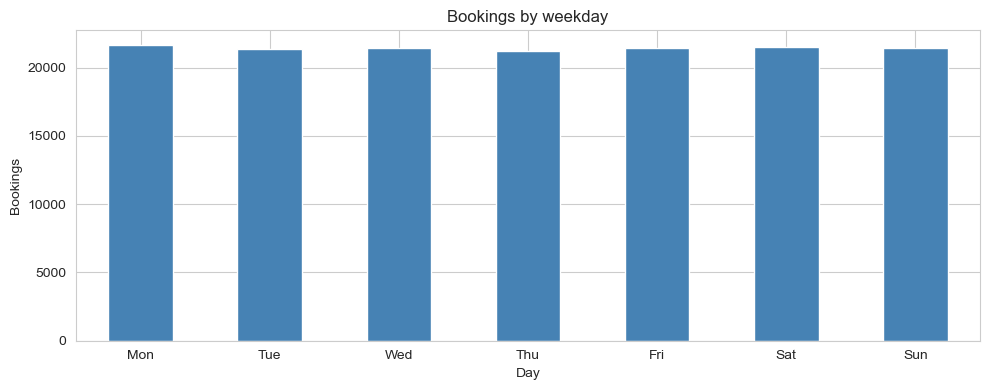

In [31]:
# Weekday vs weekend comparison
wd_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
weekday_counts = df_clean.groupby('booking_weekday').size()
weekday_counts.index = [wd_names[i] for i in weekday_counts.index]
weekend = df_clean[df_clean['weekend_flag']==1]
weekday = df_clean[df_clean['weekend_flag']==0]

plt.figure(figsize=(10, 4))
weekday_counts.plot(kind='bar', color='steelblue')
plt.title('Bookings by weekday')
plt.xlabel('Day')
plt.ylabel('Bookings')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### C. Vehicle Analysis

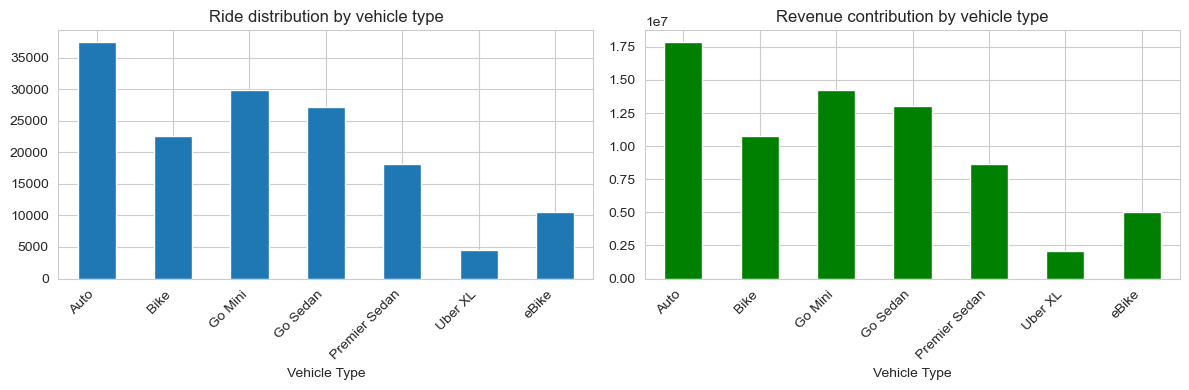

In [33]:
by_vehicle = df_clean.groupby(vt_col).agg(
    bookings=(vt_col, 'count'),
    revenue=(fare_col, 'sum'),
    avg_fare=(fare_col, 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
by_vehicle.plot(x=vt_col, y='bookings', kind='bar', ax=axes[0], legend=False)
axes[0].set_title('Ride distribution by vehicle type')
axes[0].set_xticklabels(by_vehicle[vt_col], rotation=45, ha='right')
by_vehicle.plot(x=vt_col, y='revenue', kind='bar', ax=axes[1], color='green', legend=False)
axes[1].set_title('Revenue contribution by vehicle type')
axes[1].set_xticklabels(by_vehicle[vt_col], rotation=45, ha='right')
plt.tight_layout()
plt.show()

### D. Cancellation Analysis

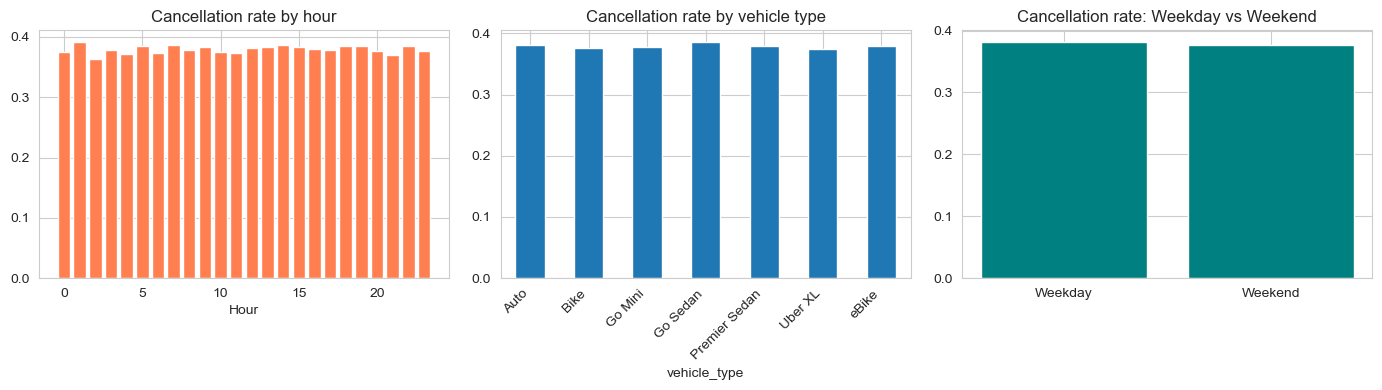

Top cancellation reasons:
cancellation_reason
Customer related issue                          6837
The customer was coughing/sick                  6751
Personal & Car related issues                   6726
More than permitted people in there             6686
Customer Demand                                 3040
Vehicle Breakdown                               3012
Other Issue                                     2948
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Name: count, dtype: int64


In [35]:
df_clean['is_cancelled'] = (~df_clean[status_col].astype(str).str.contains('Completed', case=False, na=False)).astype(int)

cancel_by_hour = df_clean.groupby('booking_hour')['is_cancelled'].mean().reset_index()
cancel_by_hour.columns = ['hour', 'cancel_rate']

cancel_by_vehicle = df_clean.groupby(vt_col)['is_cancelled'].mean().reset_index()
cancel_by_vehicle.columns = ['vehicle_type', 'cancel_rate']

cancel_weekend = df_clean.groupby('weekend_flag')['is_cancelled'].mean()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(cancel_by_hour['hour'], cancel_by_hour['cancel_rate'], color='coral')
axes[0].set_title('Cancellation rate by hour')
axes[0].set_xlabel('Hour')
cancel_by_vehicle.plot(x='vehicle_type', y='cancel_rate', kind='bar', ax=axes[1], legend=False)
axes[1].set_title('Cancellation rate by vehicle type')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[2].bar(['Weekday','Weekend'], [cancel_weekend.get(0,0), cancel_weekend.get(1,0)], color='teal')
axes[2].set_title('Cancellation rate: Weekday vs Weekend')
plt.tight_layout()
plt.show()

reasons = df_clean[df_clean['is_cancelled']==1]['cancellation_reason'].value_counts()
reasons = reasons[reasons.index != 'Unknown']
print('Top cancellation reasons:'); print(reasons.head(10))

### E. Visualizations – Heatmap, Boxplots

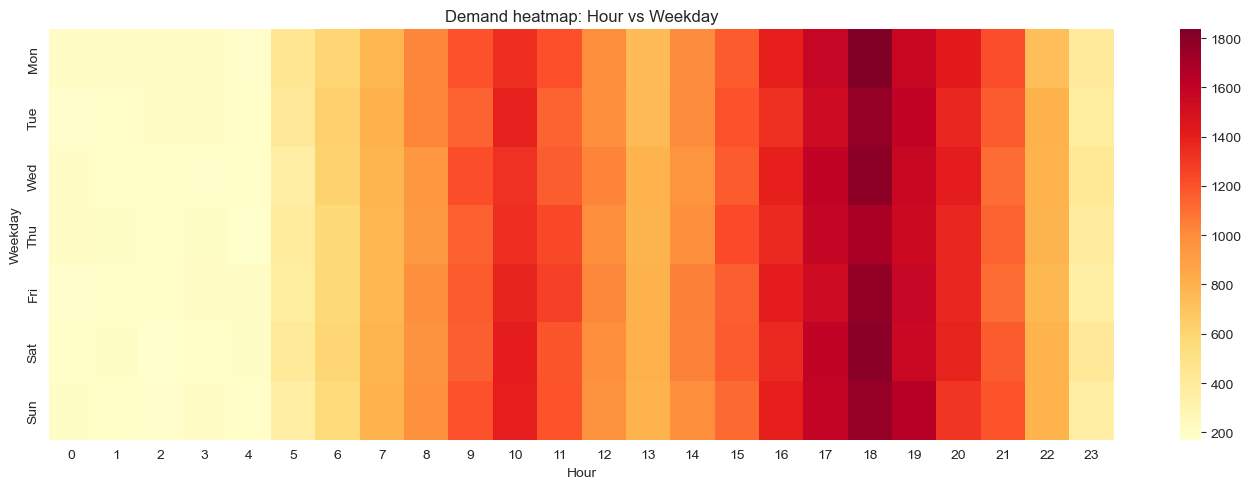

In [37]:
heatmap_data = df_clean.pivot_table(values='Booking ID', index='booking_weekday', columns='booking_hour', aggfunc='count', fill_value=0)
if heatmap_data.size > 0:
    heatmap_data.index = [wd_names[i] for i in heatmap_data.index]
    plt.figure(figsize=(14, 5))
    sns.heatmap(heatmap_data, cmap='YlOrRd', fmt='d')
    plt.title('Demand heatmap: Hour vs Weekday')
    plt.xlabel('Hour')
    plt.ylabel('Weekday')
    plt.tight_layout()
    plt.show()

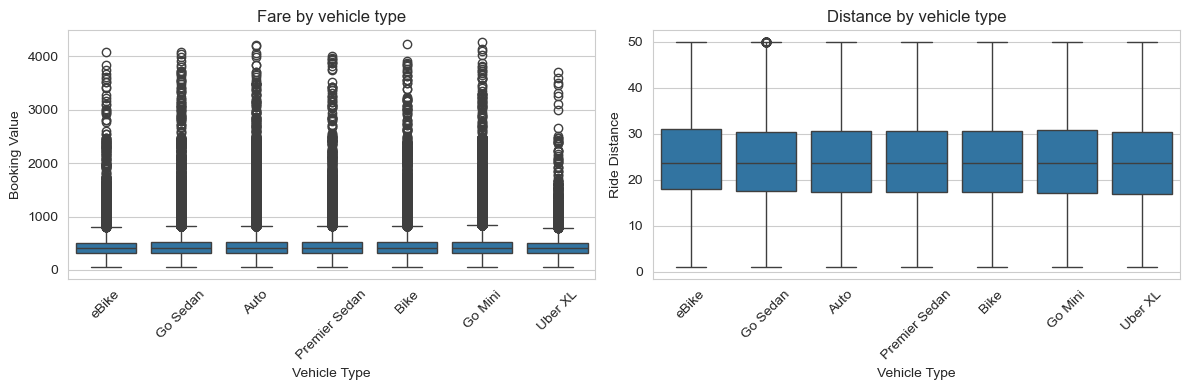

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df_clean, x=vt_col, y=fare_col, ax=axes[0])
axes[0].set_title('Fare by vehicle type')
axes[0].tick_params(axis='x', rotation=45)
sns.boxplot(data=df_clean, x=vt_col, y=dist_col, ax=axes[1])
axes[1].set_title('Distance by vehicle type')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [39]:
print((df_clean.isnull().sum() / len(df) * 100).round(2))

Date                                 0.0
Time                                 0.0
Booking ID                           0.0
Booking Status                       0.0
Customer ID                          0.0
Vehicle Type                         0.0
Pickup Location                      0.0
Drop Location                        0.0
Avg VTAT                             0.0
Avg CTAT                             0.0
Reason for cancelling by Customer    0.0
Driver Cancellation Reason           0.0
Incomplete Rides Reason              0.0
Booking Value                        0.0
Ride Distance                        0.0
Driver Ratings                       0.0
Customer Rating                      0.0
Payment Method                       0.0
booking_datetime                     0.0
booking_hour                         0.0
booking_day                          0.0
booking_weekday                      0.0
booking_month                        0.0
weekend_flag                         0.0
ride_duration_mi

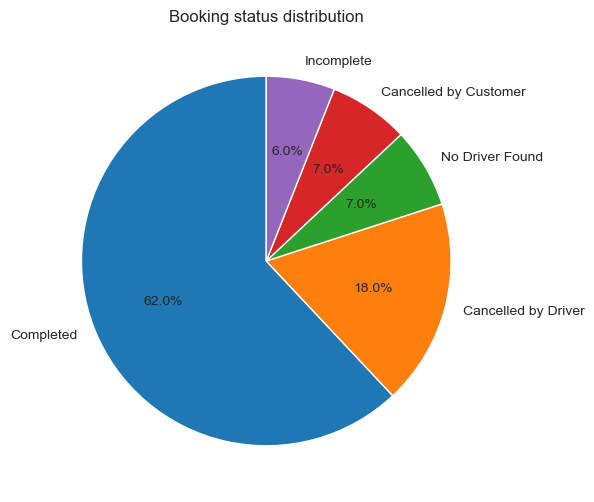

In [40]:
status_counts = df_clean[status_col].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Booking status distribution')
plt.show()